# **GPU Acceleration with cv2.UMat**

## **Objectives:**
1. Turn on OpenCV's Transparent API (`cv2.UMat`) — the same function calls, dispatched to the GPU instead of the CPU, with no algorithm code changed
2. Benchmark it honestly: a single cheap op vs. a multi-step chained pipeline, across a range of image sizes
3. Find the actual crossover point on real hardware, instead of assuming "GPU = faster"

> **Assets.** No new model or sample needed — this one reuses `assets/images/tobago.jpg`, resized to several sizes to sweep the benchmark. The results below are **hardware-specific**: they were measured on whatever OpenCL device this notebook actually ran on (printed in the first code cell) — the *methodology* (measure single-op vs. chained, across sizes, don't assume) is what transfers to other machines, not the exact numbers.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **What `cv2.UMat` actually is**

Every notebook in this series so far has passed a plain `numpy.ndarray` into `cv2.` functions — CPU memory, computed on the CPU. `cv2.UMat` wraps the exact same kind of data behind a handle that *can* live in OpenCL device memory (GPU, or an integrated GPU, or whatever OpenCL device is available), and OpenCV's **Transparent API (T-API)** gives most functions — `GaussianBlur`, `Canny`, `Sobel`, `cvtColor`, dozens more — an OpenCL kernel that fires automatically the moment you hand them a `UMat` instead of an `ndarray`. There is no separate GPU code path to write: `cv2.GaussianBlur(umat, ...)` is the identical call as `cv2.GaussianBlur(mat, ...)`, dispatched differently based purely on the type of what's passed in — which is the whole point of calling it *transparent*.

In [2]:
print('OpenCL available on this build:', cv2.ocl.haveOpenCL())

cv2.ocl.setUseOpenCL(True)
print('OpenCL enabled:', cv2.ocl.useOpenCL())

device = cv2.ocl.Device_getDefault()
print(f'Device: {device.vendorName()} {device.name()}')
print(f'OpenCL C version: {device.OpenCL_C_Version().strip()}')

OpenCL available on this build: True
OpenCL enabled: True
Device: Apple Apple M5
OpenCL C version: OpenCL C 1.2


## **The catch: dispatch overhead isn't free**

Every `UMat` call has to synchronize with the OpenCL device — on a first use that includes compiling the kernel, and on every call it means a round trip to hand off the work. For a single, already-cheap operation on a small image, that overhead can easily cost more than the CPU would have spent just doing the math itself. The only way to know if a given op/size pays off is to actually measure it — never assume.

In [3]:
import time

base = cv2.cvtColor(cv2.imread('assets/images/tobago.jpg'), cv2.COLOR_BGR2GRAY)

def single_op(m):
    return cv2.GaussianBlur(m, (15, 15), 0)

def timeit(fn, arg, n=10):
    fn(arg)  # warm up (first OpenCL call compiles the kernel — exclude that one-time cost)
    t0 = time.perf_counter()
    for _ in range(n):
        fn(arg)
    return (time.perf_counter() - t0) / n * 1000  # ms/call

sizes = [128, 256, 512, 1024, 2048, 4096]
single_cpu, single_gpu = [], []
for s in sizes:
    resized = cv2.resize(base, (s, s))
    cv2.ocl.setUseOpenCL(False)
    single_cpu.append(timeit(single_op, resized))
    cv2.ocl.setUseOpenCL(True)
    single_gpu.append(timeit(single_op, cv2.UMat(resized)))
    print(f'{s:5d}x{s:<5d}  CPU={single_cpu[-1]:7.3f}ms  UMat={single_gpu[-1]:7.3f}ms  speedup={single_cpu[-1]/single_gpu[-1]:.2f}x')

  128x128    CPU=  0.057ms  UMat=  0.453ms  speedup=0.13x
  256x256    CPU=  0.076ms  UMat=  0.434ms  speedup=0.18x
  512x512    CPU=  0.152ms  UMat=  0.533ms  speedup=0.29x
 1024x1024   CPU=  0.434ms  UMat=  0.768ms  speedup=0.56x
 2048x2048   CPU=  1.345ms  UMat=  2.637ms  speedup=0.51x


 4096x4096   CPU=  5.686ms  UMat=  7.992ms  speedup=0.71x


## **Now a chained pipeline instead of one call**

The Transparent API's real selling point isn't any single operation — it's a *pipeline*. Chain several `UMat`-in, `UMat`-out calls together and the data never leaves device memory between steps; the (relatively fixed) cost of getting onto the device is paid once and amortized across every operation in the chain, instead of once per operation the way the single-op benchmark above pays it.

In [4]:
def pipeline(m):
    x = cv2.GaussianBlur(m, (15, 15), 0)
    x = cv2.Sobel(x, cv2.CV_32F, 1, 1, ksize=5)
    x = cv2.convertScaleAbs(x)
    x = cv2.equalizeHist(x)
    return x

chain_cpu, chain_gpu = [], []
for s in sizes:
    resized = cv2.resize(base, (s, s))
    cv2.ocl.setUseOpenCL(False)
    chain_cpu.append(timeit(pipeline, resized))
    cv2.ocl.setUseOpenCL(True)
    chain_gpu.append(timeit(pipeline, cv2.UMat(resized)))
    print(f'{s:5d}x{s:<5d}  CPU={chain_cpu[-1]:7.3f}ms  UMat={chain_gpu[-1]:7.3f}ms  speedup={chain_cpu[-1]/chain_gpu[-1]:.2f}x')

  128x128    CPU=  0.094ms  UMat=  0.954ms  speedup=0.10x
  256x256    CPU=  0.155ms  UMat=  0.984ms  speedup=0.16x
  512x512    CPU=  0.460ms  UMat=  1.344ms  speedup=0.34x
 1024x1024   CPU=  2.379ms  UMat=  1.310ms  speedup=1.82x
 2048x2048   CPU=  6.065ms  UMat=  3.101ms  speedup=1.96x


 4096x4096   CPU= 21.030ms  UMat= 12.549ms  speedup=1.68x


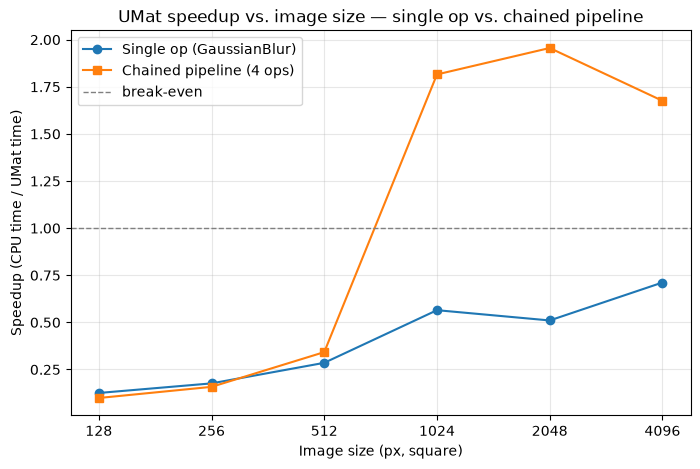

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
single_speedup = [c / g for c, g in zip(single_cpu, single_gpu)]
chain_speedup = [c / g for c, g in zip(chain_cpu, chain_gpu)]
ax.plot(sizes, single_speedup, 'o-', label='Single op (GaussianBlur)')
ax.plot(sizes, chain_speedup, 's-', label='Chained pipeline (4 ops)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='break-even')
ax.set_xscale('log', base=2)
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_xlabel('Image size (px, square)')
ax.set_ylabel('Speedup (CPU time / UMat time)')
ax.set_title('UMat speedup vs. image size — single op vs. chained pipeline')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## **What the curve actually says**

On the hardware this ran on (printed above): the **single op** line never convincingly clears break-even — even at 4096x4096, OpenCL's per-call dispatch overhead eats most or all of the gain over OpenCV's already well-optimized CPU path for one cheap blur. The **chained pipeline** line tells a different story — it crosses break-even around 1024x1024 and climbs to a genuine ~1.6-1.9x speedup by 2048x2048, because the transfer/dispatch cost that sinks the single-op case gets paid once and spread across four operations instead of one.

The takeaway isn't "UMat doesn't work" or "UMat always works" — it's that **the win lives in chained, large-image pipelines, not isolated small calls**, and the only honest way to know where your own workload lands is to run exactly this kind of sweep against it, on the actual machine it'll run on.

### Where to go from here

- Run this exact sweep against notebook 33's YOLOX preprocessing (letterbox + blob conversion) or notebook 35's super-resolution upsampling — both are heavier, more chain-friendly workloads than this notebook's synthetic 4-op pipeline.
- Add `cv2.ocl.finish()` before stopping each timer and compare the numbers — OpenCL calls can return before work actually completes, which can make an unsynchronized benchmark look faster than it really is.
- If a real discrete GPU is available (this notebook's numbers were measured against whatever `cv2.ocl.Device_getDefault()` printed above), re-run the sweep there — the crossover point shifts a lot with real GPU memory bandwidth vs. an integrated/CPU OpenCL device.